# Securing MCP Servers with OAuth 2.1

In the previous notebook, we connected to an **unauthenticated** MCP server - anyone could access it. But in production, MCP servers need **security** to protect sensitive data and control who can perform operations.

This notebook introduces **MCP Security** using OAuth 2.1 authentication.

## The Security Flow

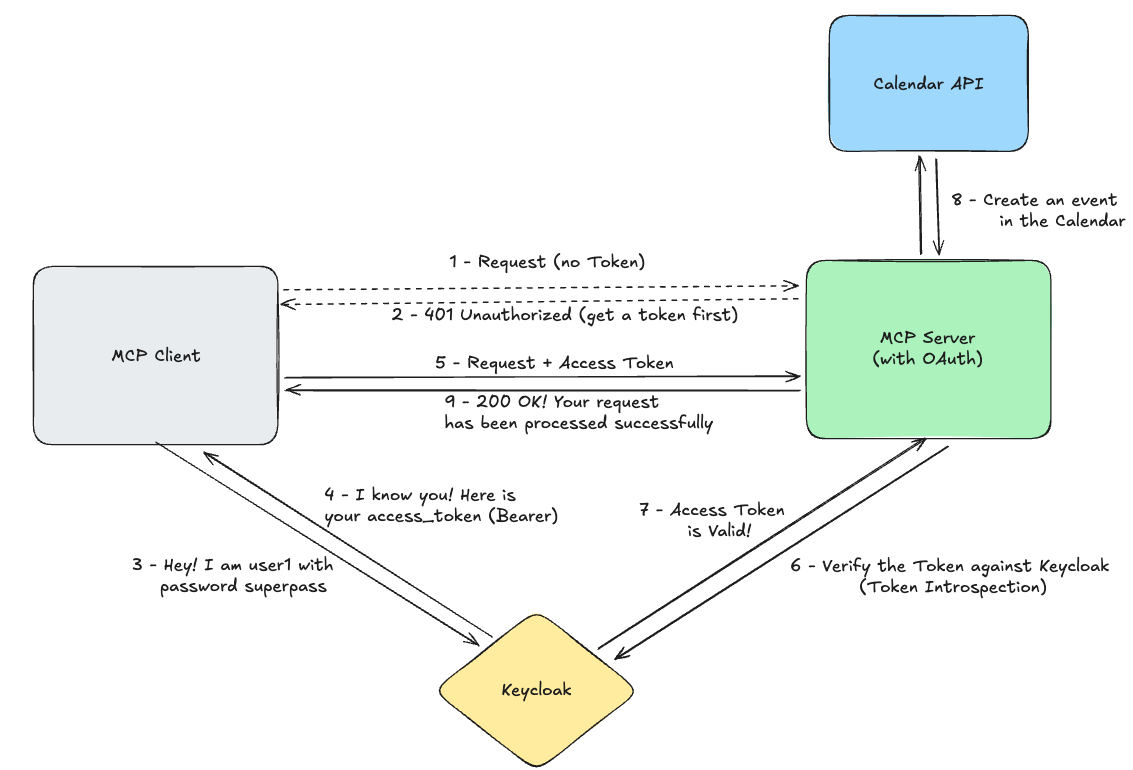

**The MCP Authorization flow:**
1. **Request (no token)** - Client tries to access MCP Server without authentication
2. **401 Unauthorized** - Server rejects the request and tells client to get a token
3. **Login to Keycloak** - Client sends credentials (username/password) to OAuth server
4. **Access Token** - Keycloak returns a Bearer token with granted scopes
5. **Request + Token** - Client retries the request with `Authorization: Bearer <token>`
6. **Token Introspection** - Server validates the token with Keycloak
7. **Token Valid** - Keycloak confirms the token is active and has required scopes
8. **Call Calendar API** - Server processes the request and calls the backend
9. **200 OK** - Server returns successful response to the client

## Setup

Because of simplicity we are using the same OAuth MCP Server with a shared Keycloak, but with different users / passwords. In other words, instead of redeploy the entire stack, you will use a preexistent secured mcp server and Keycloak setup.

In [ ]:
# !!!!!IMPORTANT!!!!! Update your User
USERNAME = "userX" # Replace with your actual user (e.g., user1, user2, etc.)
PASSWORD = "thisisthepassword"
CLUSTER_DOMAIN = "apps.example.com" # Replace with your cluster's domain

In [ ]:
import httpx
import json
from datetime import datetime, timedelta

# Suppress verbose logging
import logging
logging.getLogger("httpx").setLevel(logging.WARNING)

# MCP Server Auth in ai501 namespace
MCP_SERVER_URL = "http://mcp-server-auth.ai501.svc:8080"
MCP_ENDPOINT = f"{MCP_SERVER_URL}/mcp"

# Keycloak in keycloak namespace (HTTP port for internal access)
KEYCLOAK_URL = "http://keycloak-service.keycloak.svc:8080"
TOKEN_ENDPOINT = f"{KEYCLOAK_URL}/realms/mcp-calendar/protocol/openid-connect/token"

# OAuth client credentials (pre-registered in Keycloak realm)
CLIENT_ID = "mcp-client"
CLIENT_SECRET = "zrqR06T0NBTct1ZP08SK8NAc8JfVRW0n"

print("MCP OAuth Demo - Internal Services")
print("=" * 50)
print(f"  MCP Server:  {MCP_SERVER_URL}")
print(f"  Keycloak:    {KEYCLOAK_URL}")
print(f"  Realm:       mcp-calendar")
print(f"  User:        {USERNAME}")

## Step 1: Security in Action - The 401 Challenge

When the MCP server is secured with OAuth, it **rejects all unauthenticated requests** with a `401 Unauthorized` response.

This is the security working as intended - the server is protecting its resources.

In [ ]:
print("Attempting to access secured MCP server WITHOUT a token...\n")

async with httpx.AsyncClient() as client:
    response = await client.get(MCP_ENDPOINT)

print(f"Response: {response.status_code} {response.reason_phrase}")

if response.status_code == 401:
    print("\nSecurity working! Server rejected the unauthenticated request.")
    print("We need a valid token to proceed.")

## Step 2: Authenticate with Keycloak

To access the secured MCP server, we request an **access token** from Keycloak.

The token proves:
- **Who we are** (user identity)
- **What we can do** (scopes/permissions)
- **How long it's valid** (expiration)

In [ ]:
print("Requesting access token from Keycloak...\n")

async with httpx.AsyncClient() as client:
    response = await client.post(
        TOKEN_ENDPOINT,
        data={
            "grant_type": "password",
            "client_id": CLIENT_ID,
            "client_secret": CLIENT_SECRET,
            "username": USERNAME,
            "password": PASSWORD,
            "scope": "openid mcp:tools",
        },
        headers={"Content-Type": "application/x-www-form-urlencoded"},
    )

if response.status_code == 200:
    token_data = response.json()
    access_token = token_data['access_token']
    
    print("Token obtained!")
    print(f"  Type:    {token_data['token_type']}")
    print(f"  Token:   {token_data['access_token'][:180]}")
    print(f"  Expires: {token_data['expires_in']} seconds")
    print(f"  Scope:   {token_data.get('scope', 'N/A')}")
else:
    print(f"Authentication failed: {response.status_code}")
    print(f"Response: {response.text}")
    access_token = None

## Step 3: Access the Secured MCP Server

With a valid token, we can now access the MCP server.

The server validates our token with Keycloak before allowing access. This ensures:
- Token is not expired or revoked
- Token was issued for this server (audience check)
- Token has the required permissions (scope check)

In [ ]:
from mcp import ClientSession
from mcp.client.sse import sse_client

print("Connecting to secured MCP server with valid token...\n")

headers = {"Authorization": f"Bearer {access_token}"}

try:
    async with sse_client(MCP_ENDPOINT, headers=headers) as (read, write):
        async with ClientSession(read, write) as session:
            await session.initialize()
            print("Access granted!\n")
            
            tools = await session.list_tools()
            
            print(f"Available tools ({len(tools.tools)}):")
            for tool in tools.tools:
                desc = tool.description.split('\n')[0] if tool.description else ''
                print(f"  - {tool.name}")
except Exception as e:
    print(f"Error: {e}")

## Step 4: Use the Secured Tools

Now we can call tools on the OAuth-protected server - both read and write operations.

In [ ]:
print("Calling get_calendar_statistics...\n")

headers = {"Authorization": f"Bearer {access_token}"}

try:
    async with sse_client(MCP_ENDPOINT, headers=headers) as (read, write):
        async with ClientSession(read, write) as session:
            await session.initialize()
            result = await session.call_tool("get_calendar_statistics", arguments={})
            
            for content in result.content:
                print(content.text)
except Exception as e:
    print(f"Error: {e}")

In [ ]:
# Create a new event (write operation)
tomorrow = datetime.now() + timedelta(days=1)
start_time = tomorrow.replace(hour=14, minute=0, second=0)
end_time = start_time + timedelta(hours=1)

event_data = {
    "name": "MCP Server OAuth Demo Event",
    "content": "Created via OAuth-authenticated MCP connection", # Feel free to change the content with your own ideas!
    "category": "Workshop",
    "level": 2,
    "start_time": start_time.strftime("%Y-%m-%d %H:%M:%S"),
    "end_time": end_time.strftime("%Y-%m-%d %H:%M:%S")
}

print(f"Creating event: {event_data['name']}\n")

headers = {"Authorization": f"Bearer {access_token}"}

try:
    async with sse_client(MCP_ENDPOINT, headers=headers) as (read, write):
        async with ClientSession(read, write) as session:
            await session.initialize()
            result = await session.call_tool("create_event", arguments=event_data)
            
            for content in result.content:
                print(content.text)
except Exception as e:
    print(f"Error: {e}")

## Verify that your Calendar Event is created

https://calendar-frontend-ai501.{{ CLUSTER_DOMAIN }} 

We demonstrated how to **secure an MCP server** and connect to it:

| Step | What Happens |
|------|-------------|
| 1. No token | Server rejects request with **401 Unauthorized** |
| 2. Authenticate | Keycloak issues **access token** with `mcp:tools` scope |
| 3. With token | MCP Server validates token and **grants access** |
| 4. Use tools | Full access to read and write operations |

### Security Benefits

- **Authentication**: Only users with valid credentials can get tokens
- **Authorization**: Scopes control what operations are allowed
- **Token Expiration**: Tokens expire, limiting exposure if compromised
- **Centralized Control**: Keycloak manages users, clients, and permissions